#IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#DATA LOADING

In [ ]:
df = pd.read_excel("Superstore_USA.xlsx")

#BASIC STRUCTURE CHECKS

In [ ]:
df.head(5)  #CHECKING FIRST 5 ROWS OF THE DATA

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,18606,Not Specified,0.01,2.88,0.50,2,Janice Fletcher,Regular Air,Corporate,Office Supplies,...,Central,Illinois,Addison,60101,2012-05-28,2012-05-30,1.3200,2,5.90,88525
1,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2010-07-07,2010-07-08,4.5600,4,13.01,88522
2,23086,Not Specified,0.03,6.68,6.15,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-28,-47.6400,7,49.92,88523
3,23087,Not Specified,0.01,5.68,3.60,3,Bonnie Potter,Regular Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-28,-30.5100,7,41.64,88523
4,23088,Not Specified,0.00,205.99,2.50,3,Bonnie Potter,Express Air,Corporate,Technology,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-27,998.2023,8,1446.67,88523


In [ ]:
df.shape # HOW MANY ROWS AND COLUMNS WE HAVE

(9426, 24)

In [ ]:
df.info() #CHECKING NULL VALUE AND DATA TYPES

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                9426 non-null   int64         
 1   Order Priority        9426 non-null   object        
 2   Discount              9426 non-null   float64       
 3   Unit Price            9426 non-null   float64       
 4   Shipping Cost         9426 non-null   float64       
 5   Customer ID           9426 non-null   int64         
 6   Customer Name         9426 non-null   object        
 7   Ship Mode             9426 non-null   object        
 8   Customer Segment      9426 non-null   object        
 9   Product Category      9426 non-null   object        
 10  Product Sub-Category  9426 non-null   object        
 11  Product Container     9426 non-null   object        
 12  Product Name          9426 non-null   object        
 13  Product Base Margi

#DATA QUALITY & MISSING VALUE ANALYSIS

In [ ]:
df.isnull().sum() # CHECKING NULL VALUES

,0
Row ID,0
Order Priority,0
Discount,0
Unit Price,0
Shipping Cost,0
Customer ID,0
Customer Name,0
Ship Mode,0
Customer Segment,0
Product Category,0


<Axes: >

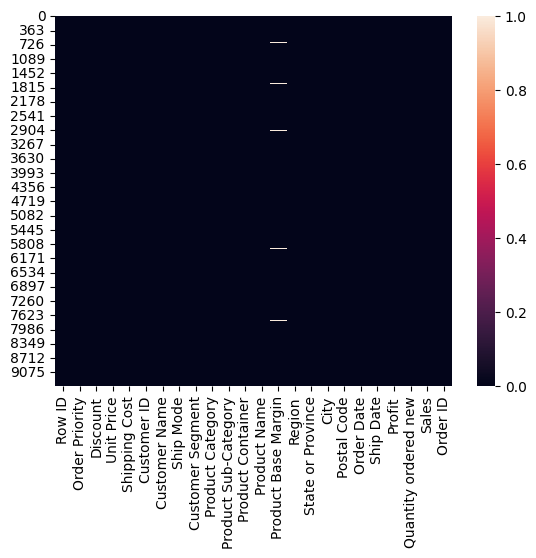

In [ ]:
sns.heatmap(df.isnull()) # VISUAL REPRESENTAION OF NULL VALUES

In [ ]:
df['Product Base Margin']=df['Product Base Margin'].fillna(df['Product Base Margin'].mean()) #FILLING NULL VALUES BY MEAN

In [ ]:
df.isnull().sum() #RECHECKING AGAIN FOR ANY MISSING VALUE

,0
Row ID,0
Order Priority,0
Discount,0
Unit Price,0
Shipping Cost,0
Customer ID,0
Customer Name,0
Ship Mode,0
Customer Segment,0
Product Category,0


#DUPLICATED RECORD CHECK

In [ ]:
df.duplicated().sum() #CHECKING FOR DUPLICATE VALUES

np.int64(0)

#DESCRIPTIVE STATISTICS

In [ ]:
df.describe()

,Row ID,Discount,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
count,9426.000000,9426.000000,9426.000000,9426.000000,9426.000000,9426.000000,9426.000000,9426,9426,9426.000000,9426.000000,9426.000000,9426.000000
mean,20241.015277,0.049628,88.303686,12.795142,1738.422236,0.512189,52446.327286,2012-03-05 18:33:59.465308672,2012-03-07 19:16:18.485041408,139.236410,13.798430,949.706272,82318.489073
min,2.000000,0.000000,0.990000,0.490000,2.000000,0.350000,1001.000000,2010-01-01 00:00:00,2010-01-02 00:00:00,-16476.838000,1.000000,1.320000,6.000000
25%,19330.250000,0.020000,6.480000,3.192500,898.000000,0.380000,29406.000000,2011-03-07 06:00:00,2011-03-09 00:00:00,-74.017375,5.000000,61.282500,86737.250000
50%,21686.500000,0.050000,20.990000,6.050000,1750.000000,0.520000,52302.000000,2012-04-08 00:00:00,2012-04-09 00:00:00,2.567600,10.000000,203.455000,88344.500000
75%,24042.750000,0.080000,85.990000,13.990000,2578.750000,0.590000,78516.000000,2013-03-26 00:00:00,2013-03-28 00:00:00,140.243850,17.000000,776.402500,89987.750000
max,26399.000000,0.250000,6783.020000,164.730000,3403.000000,0.850000,99362.000000,2013-12-31 00:00:00,2014-01-17 00:00:00,16332.414000,170.000000,100119.160000,91591.000000
std,6101.890965,0.031798,281.540982,17.181203,979.167197,0.134711,29374.597802,NaN,NaN,998.486483,15.107688,2598.019818,19149.448857


#Categorical Feature Exploration

In [ ]:
df['Order Priority'].value_counts() #CHECKING COUNT OF UNIQUE TYPES OF ORDER PRIORITY

,count
Order Priority,
High,1970
Low,1926
Not Specified,1881
Medium,1844
Critical,1804
Critical,1


Before starting analysis, I checked the structure, data types, missing values, and duplicates to ensure data quality.

Date columns were converted to datetime format so that time-based trends like monthly and yearly sales could be analyzed accurately.

#SALES PERFORMANCE ANALYSIS

In [ ]:
# Total & average sales
total_sales = df['Sales'].sum()
avg_sales = df['Sales'].mean()

total_sales, avg_sales


(np.float64(8951931.32), np.float64(949.7062720135795))

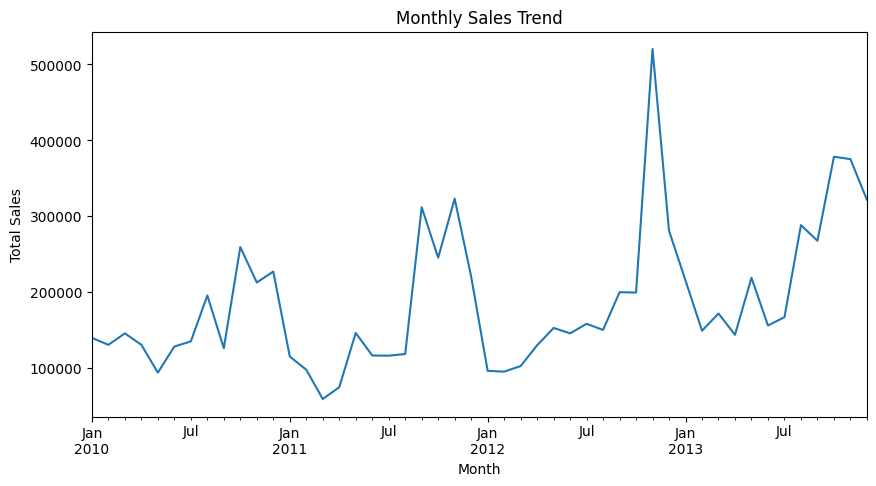

In [ ]:
# Monthly sales trend
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()

monthly_sales.plot(kind='line', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


Insight from the plot:

From the monthly sales trend, we can clearly observe how sales behave over time.
There are visible fluctuations, indicating seasonality, where certain months consistently perform better than others.

This kind of pattern is useful for forecasting future demand and planning inventory and marketing campaigns during high-sales periods.

#PROFITABILITY ANALYSIS

In [ ]:
# Total & average profit
df['Profit'].sum(), df['Profit'].mean()


(np.float64(1312442.3994276498), np.float64(139.23640986926054))

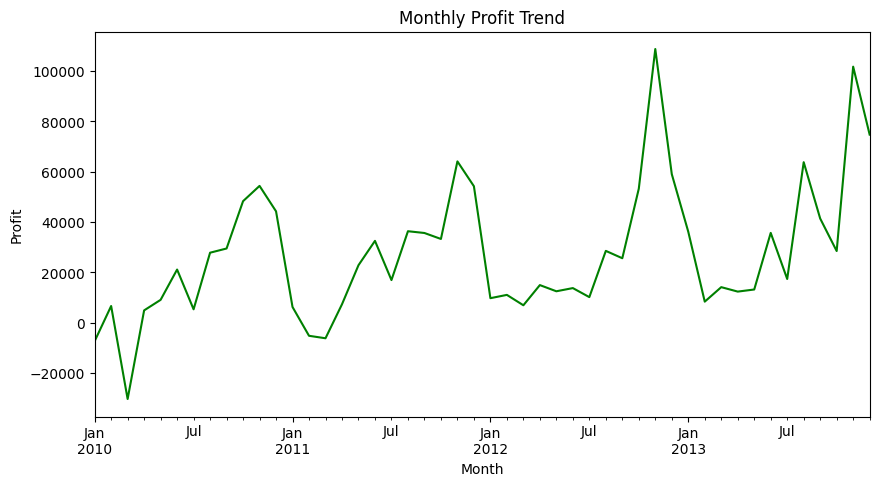

In [ ]:
# Profit trend over time
monthly_profit = df.groupby('Order Month')['Profit'].sum()

monthly_profit.plot(kind='line', figsize=(10,5), color='green')
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()


Monthly Profit Trend:

The profit trend does not always move in the same direction as sales.

This indicates that high revenue months are not always the most profitable, which suggests the impact of factors like discounts, shipping costs, or product mix.

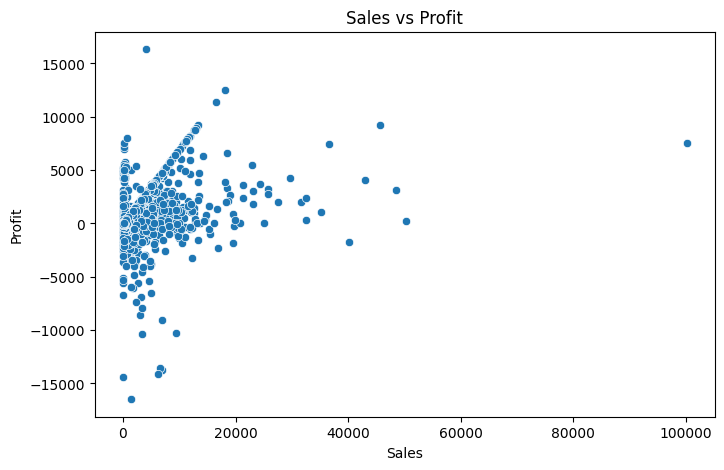

In [ ]:
# Sales vs Profit relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()


Sales vs Profit with Scatter Plot:

This scatter plot shows that while many high-sales orders are profitable, there are also several high-sales but loss-making orders.

This clearly highlights that sales volume alone is not enough, and profitability needs to be analyzed separately.

#DISCOUNT IMPACT ANALYSIS

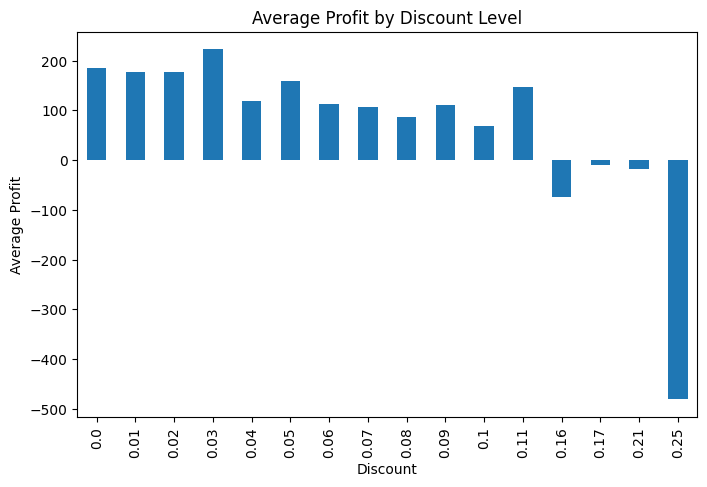

In [ ]:
# Average profit by discount
df.groupby('Discount')['Profit'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()


In [ ]:
# High discount loss analysis
df[df['Discount'] > 0.1][['Sales', 'Profit']].head()


,Sales,Profit
5990,272.61,147.660
5991,27.96,-9.130
6000,319.30,-74.510
8649,181.03,-481.041
8661,153.87,-17.750


Average Profit by Discount Level:

From this plot, we can see a negative relationship between discount and profit.
As discount levels increase, average profit tends to decrease and even turn negative at higher discount values.

This suggests that aggressive discounting may increase sales volume but hurts overall profitability.

#PRODUCT CATEGORY ANALYSIS

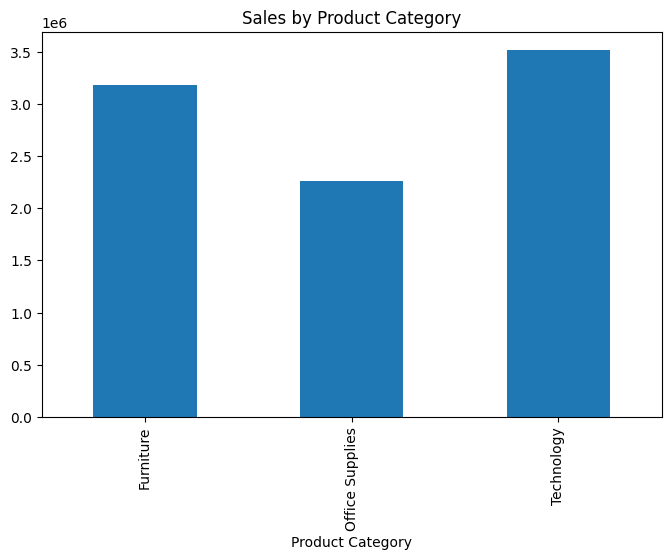

In [ ]:
# Sales by product category
df.groupby('Product Category')['Sales'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Sales by Product Category")
plt.show()


Sales by Product Category:

This chart shows which product categories contribute the most to overall revenue.
It helps identify core revenue-generating categories that should be prioritized in inventory and marketing strategies.

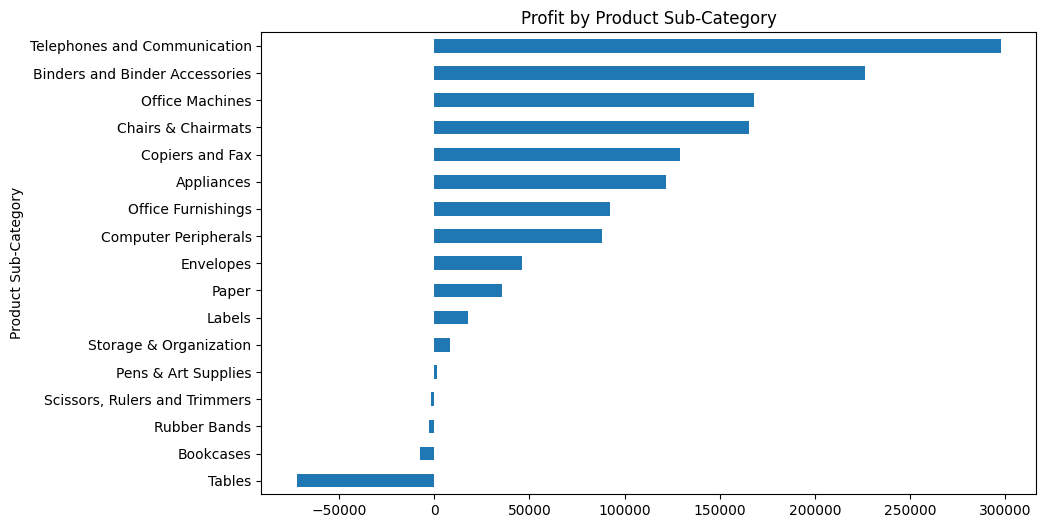

In [ ]:
# Profit by sub-category
df.groupby('Product Sub-Category')['Profit'].sum().sort_values().plot(
    kind='barh', figsize=(10,6)
)
plt.title("Profit by Product Sub-Category")
plt.show()


Profit by Product Sub-Category:

Interestingly, some sub-categories generate losses despite having decent sales.
This insight is crucial because it helps businesses re-evaluate pricing, discounts, or even discontinue unprofitable products.

#CUSTOMER SEGMENT ANALYSIS

In [ ]:
# Sales & profit by customer segment
segment_analysis = df.groupby('Customer Segment')[['Sales','Profit']].sum()
segment_analysis


,Sales,Profit
Customer Segment,,
Consumer,1835215.22,206559.625348
Corporate,3269391.07,505538.627783
Home Office,2168952.03,283869.553814
Small Business,1678373.00,316474.592482


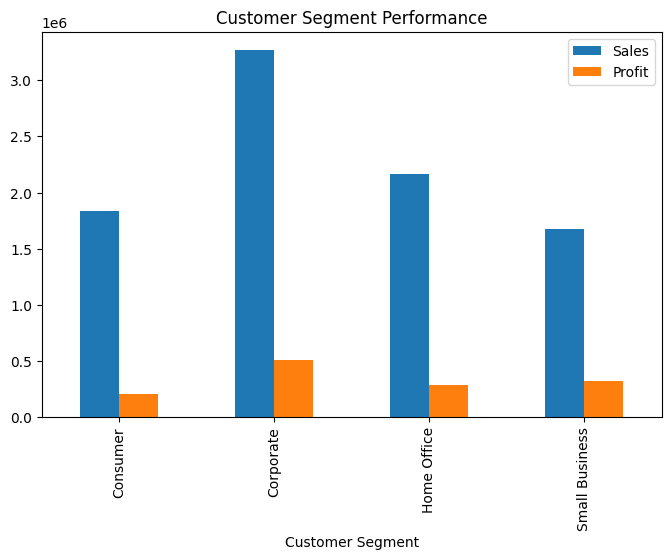

In [ ]:
segment_analysis.plot(kind='bar', figsize=(8,5))
plt.title("Customer Segment Performance")
plt.show()


Sales & Profit by Customer Segment:

From this analysis, we can identify which customer segment is the most valuable.
Some segments may generate high sales but relatively lower profit, while others are more efficient in terms of profitability, helping in targeted marketing and customer retention strategies.

#REGIONAL ANALYSIS

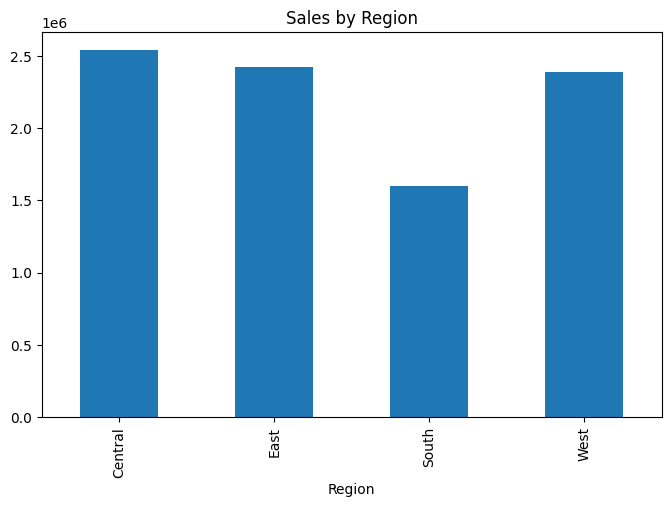

In [ ]:
# Sales by region
df.groupby('Region')['Sales'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Sales by Region")
plt.show()


Sales by Region:

This plot highlights regional performance differences.
Certain regions clearly outperform others, while some consistently underperform.
These insights can be used for regional expansion, cost control, or localized promotions.

In [ ]:
# Top 10 states by sales
df.groupby('State or Province')['Sales'].sum().sort_values(ascending=False).head(10)


,Sales
State or Province,
California,1161720.84
New York,839593.73
Illinois,667797.16
Texas,543089.00
Washington,508816.41
Florida,503609.51
Michigan,324593.62
Pennsylvania,297371.70
Ohio,290286.12


Top States by Sales:

The top-performing states contribute a significant portion of total revenue, indicating geographic concentration of demand.

#SHIPPING & LOGISTICS ANALYSIS

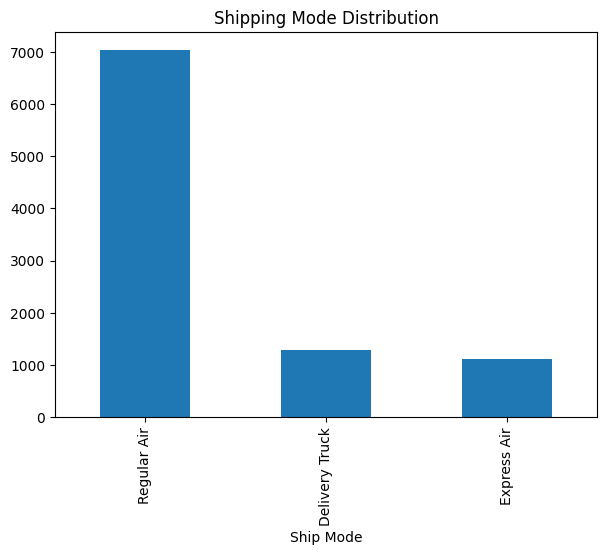

In [ ]:
# Shipping mode usage
df['Ship Mode'].value_counts().plot(kind='bar', figsize=(7,5))
plt.title("Shipping Mode Distribution")
plt.show()


Shipping Mode Distribution:

This chart shows the most frequently used shipping modes.
Understanding this helps assess whether the most commonly used modes are also cost-effective and profitable.

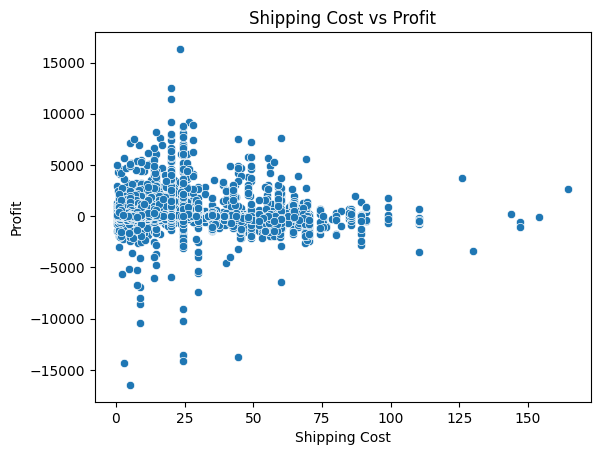

In [ ]:
# Shipping cost vs profit
sns.scatterplot(x='Shipping Cost', y='Profit', data=df)
plt.title("Shipping Cost vs Profit")
plt.show()


Shipping Cost vs Profit:

The scatter plot indicates that higher shipping costs often lead to lower or negative profit.
This suggests that logistics optimization is a key area for improving margins.

#Order Priority Analysis

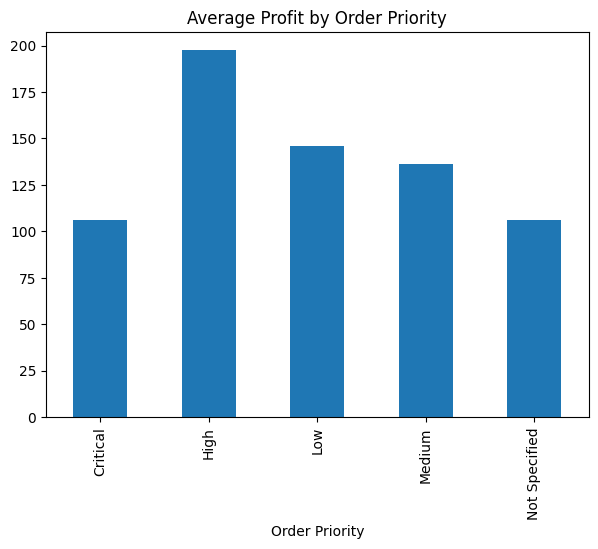

In [ ]:
df.groupby('Order Priority')['Profit'].mean().plot(kind='bar', figsize=(7,5))
plt.title("Average Profit by Order Priority")
plt.show()


Average Profit by Order Priority:

From this plot, we can analyze whether high-priority orders actually generate higher profit.

In many cases, urgent orders may incur additional costs without a proportional increase in revenue.

#Customer-Level Analysis

In [ ]:
# Top 10 customers by sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)


,Sales
Customer Name,
Gordon Brandt,123745.62
Glen Caldwell,89269.70
Rosemary O'Brien,86540.75
Leigh Burnette Hurley,83651.70
Kristine Connolly,81296.39
Nina Horne Kelly,78243.60
Neal Wolfe,69118.00
Priscilla Kane,61610.60
Dana Teague,61298.98


Top Customers by Sales:

This analysis helps identify high-value customers who contribute significantly to revenue and should be retained through loyalty programs.

In [ ]:
# Customers with losses
df.groupby('Customer Name')['Profit'].sum().sort_values().head(10)


,Profit
Customer Name,
Dean Solomon,-15865.728500
Derek Jernigan,-15290.478000
Lori Wolfe,-14441.297580
James Dickinson Ball,-13553.400088
Vicki Womble,-13146.320880
Cynthia Khan,-10906.348396
Carole Rosen,-10209.228300
Herbert Currie,-9621.040275
Gary Walton,-8437.645200


Loss-Making Customers:

Some customers consistently generate losses, which may be due to high discounts, returns, or shipping costs.

This insight helps in revising customer-specific pricing or policies.

#QUANTITY ANALYSIS

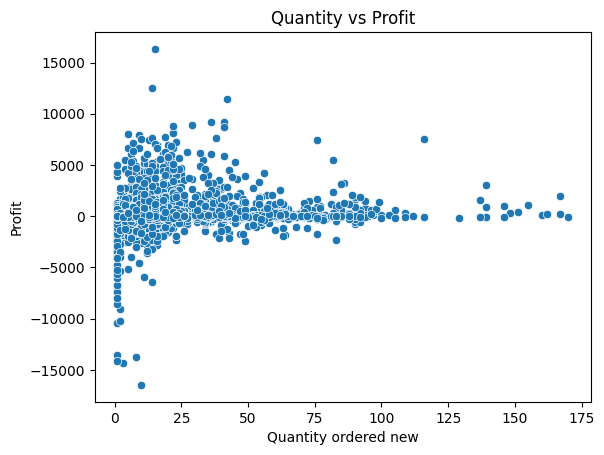

In [ ]:
sns.scatterplot(x='Quantity ordered new', y='Profit', data=df)
plt.title("Quantity vs Profit")
plt.show()


Quantity vs Profit:

The plot shows that higher quantities do not always lead to higher profit.
Bulk orders often involve heavy discounts, which can reduce margins.
This insight helps in designing better bulk pricing strategies.

#Shipping Time Analysis

In [ ]:
# Shipping delay calculation
df['Shipping Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Shipping Delay'].describe()


,Shipping Delay
count,9426.000000
mean,2.029387
std,2.301582
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,92.000000


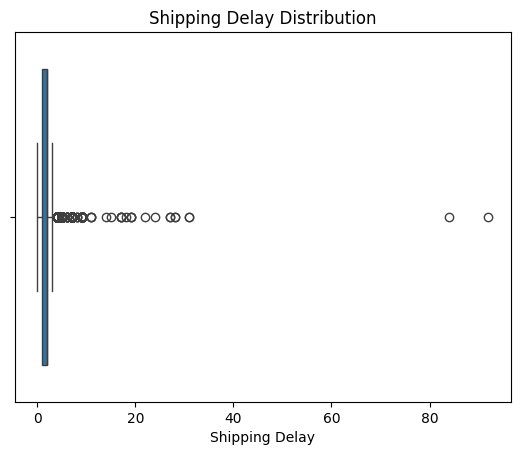

In [ ]:
sns.boxplot(x='Shipping Delay', data=df)
plt.title("Shipping Delay Distribution")
plt.show()


Shipping Delay Distribution:

Most orders are shipped within a reasonable timeframe, but there are some outliers with long delays.

Such delays can impact customer satisfaction and repeat business, even if profit is not directly affected.

#OUTLIER DETECTION

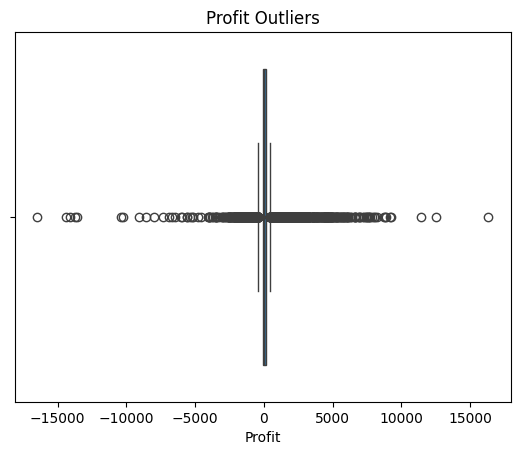

In [ ]:
sns.boxplot(x=df['Profit'])
plt.title("Profit Outliers")
plt.show()


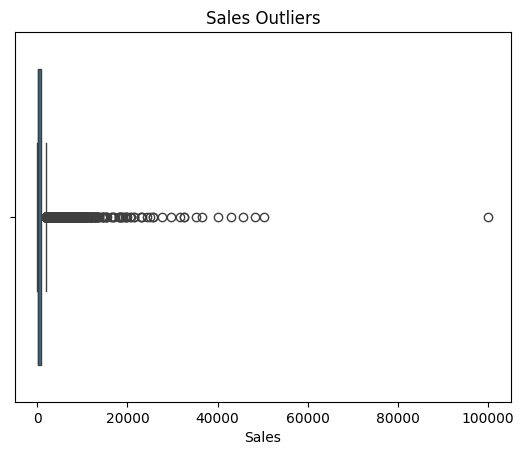

In [ ]:
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()


Sales & Profit Boxplots:

The presence of outliers indicates a small number of extremely high sales or loss-making orders.

Identifying these helps prevent them from skewing average metrics and allows deeper investigation into exceptional cases.

#CORRELATION ANALYSIS

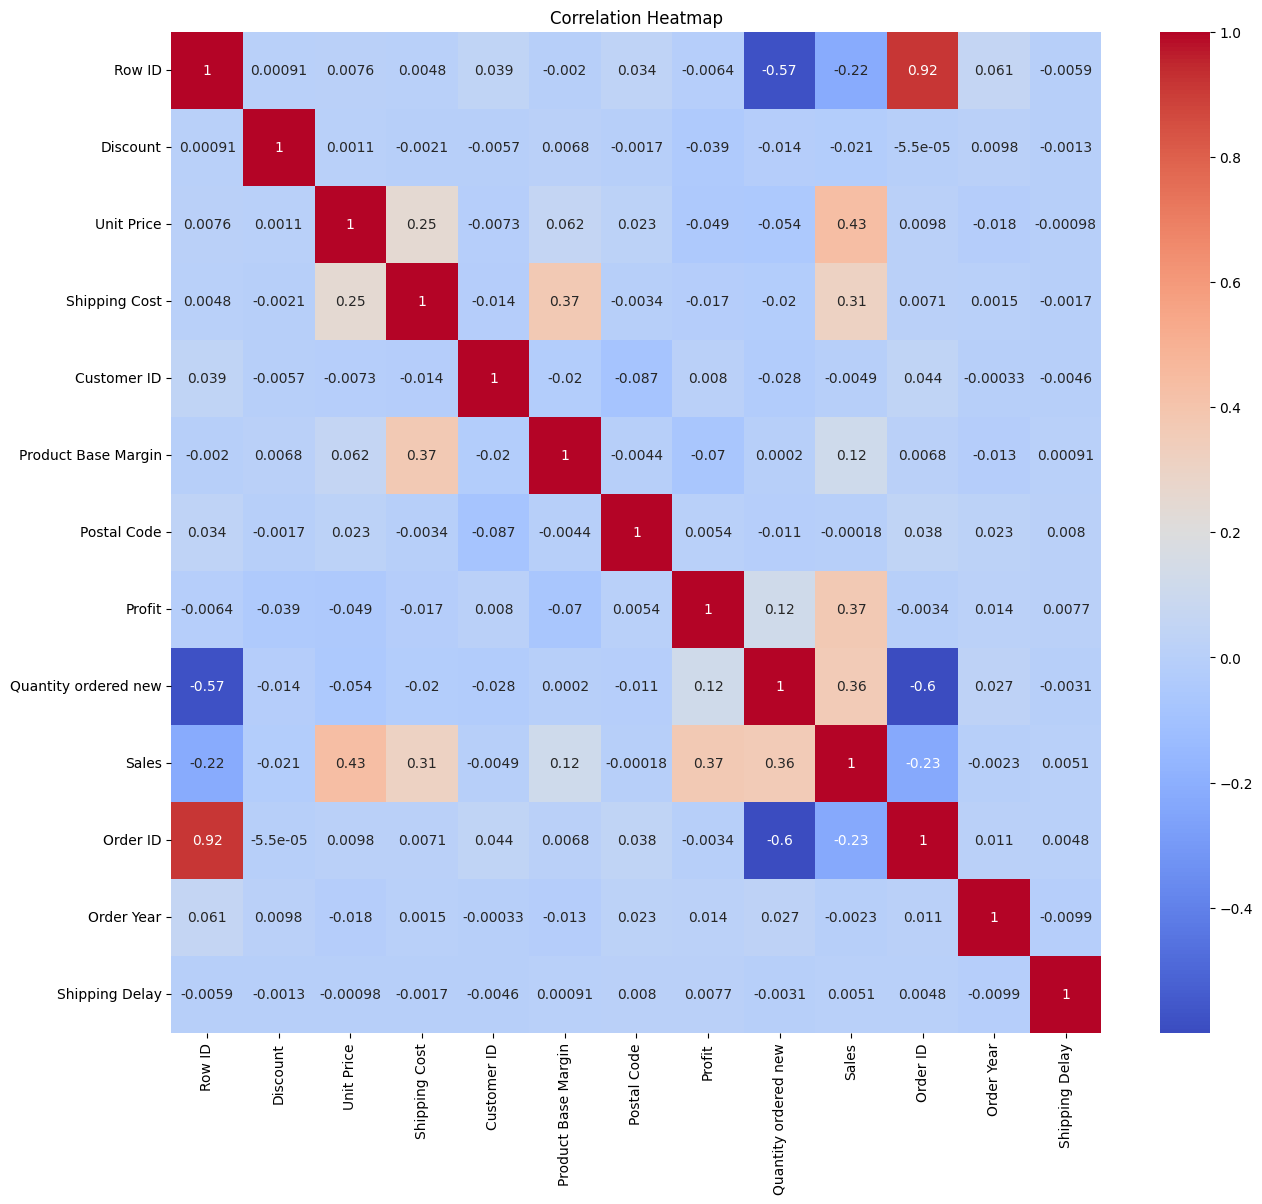

In [ ]:
plt.figure(figsize=(15,13))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Correlation Heatmap:

The heatmap shows how numerical variables relate to each other.

For example, discount shows a negative correlation with profit, reinforcing earlier findings.

This analysis is helpful for feature selection and business decision-making.

#Final Business Takeaways

Overall, this EDA reveals that profitability is influenced by multiple factors such as discounts, shipping cost, product category, and region.

The analysis helps identify where the business should focus to maximize profit rather than just sales.